# 03b — Phase 2: shoreline EXTRACTION (run often)

Extracts sub-pixel shorelines using classifiers **loaded from Google Drive**. This
notebook **never trains** — there is no reachable `train_classifier`/`train_group`
call. If a needed model is missing it tells you to run **Notebook 03a**; it does
not train a fallback.

Thin driver of `src/extract.py`. Memory is bounded: `classify_scene` runs in row
blocks, `extract_all` frees each scene (+ `gc`) and prints per-scene peak RAM, so
the 829-scene Series B batch stays flat and under Colab's ~12 GB.

**Order:** mount Drive → build scene lists → load classifiers → build/load
transects → single-scene envelope QC → batch extract (Series A, then B) →
benchmark.

## Setup — clone-or-pull, authenticate GEE, import & reload `src/`

In [1]:
import os
REPO_DIR = '/content/Shoreline-Dynamics'
# Clone-or-pull so Colab always runs the latest committed code.
if os.path.isdir(REPO_DIR):
    !cd {REPO_DIR} && git pull -q
else:
    !git clone https://github.com/SKPrince1911/Shoreline-Dynamics.git {REPO_DIR}
%cd {REPO_DIR}
!pip install -q -r requirements.txt

Cloning into '/content/Shoreline-Dynamics'...
remote: Enumerating objects: 541, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 541 (delta 43), reused 30 (delta 14), pack-reused 465 (from 1)
Receiving objects: 100% (541/541), 14.14 MiB | 18.98 MiB/s, done.
Resolving deltas: 100% (359/359), done.
/content/Shoreline-Dynamics
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 17.9 MB/s eta 0:00:00


In [2]:
import ee, geemap
ee.Authenticate()
ee.Initialize(project='shoreline-analysis')
print('GEE initialized:', ee.String('ok').getInfo())

GEE initialized: ok


In [3]:
import sys; sys.path.append('.')
import importlib
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
from src import config, data, extract
# Pick up freshly pulled modules without a kernel restart (config before its
# dependents). extract is on the reload list so edits to src/extract.py land.
importlib.reload(config); importlib.reload(data); importlib.reload(extract)

aoi = ee.Geometry.Polygon(config.aoi_coordinates())
print('feature dim:', extract.feats_dim(),
      '| default index:', config.WATER_INDEX_DEFAULT,
      '| threshold:', config.THRESHOLD_METHOD_DEFAULT)
print('sensor groups:', extract.SENSOR_GROUP)

feature dim: 20 | default index: mndwi | threshold: otsu
sensor groups: {'L4': 'TM', 'L5': 'TM', 'L7': 'TM', 'L8': 'OLI', 'L9': 'OLI', 'S2': 'MSI'}


## Mount Google Drive

Mount Drive so trained classifiers and exports read from / write to
`/content/drive/MyDrive/shoreline_dynamics/` and **survive a runtime restart**.
Skip only if you deliberately want everything under the (wiped-on-restart) repo
`models/`/`outputs/`.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Scene list — Series A (annual)

Series A explodes the approved inventory into one row per **acquisition date**
(same-overpass granules mosaicked; multi-date composites split), so every scene
keeps its own timestamp for Phase 3.

In [5]:
# Cached to Drive (then local outputs/); rebuilt from the inventory if absent — fast.
annual = extract.get_scene_list_annual()
n_years = annual['dry_year'].nunique()
print(f'Series A: {len(annual)} scenes across {n_years} dry-season-years')
assert n_years == 38, f'expected 38 non-gap years, got {n_years}'
assert annual['acq_datetime_utc'].notna().all(), 'found a NaT timestamp!'
print('sensors:', annual['sensor'].value_counts().to_dict())

loaded scene_list_annual.csv from cache (60 scenes) <- /content/drive/MyDrive/shoreline_dynamics/cache/scene_list_annual.csv
Series A: 60 scenes across 38 dry-season-years
sensors: {'L5': 35, 'L7': 10, 'S2': 8, 'L8': 6, 'L9': 1}


## Scene list — Series B (dense, all-season)  — **cached**

The dense query hits Earth Engine for hundreds of scenes and is **slow** (tens of
minutes to ~2 hours). `get_scene_list_dense()` **loads the cached
`scene_list_dense.csv` from Drive (then local `outputs/`) in seconds** and only
re-queries EE when the cache is missing/invalid or `FORCE_REBUILD_DENSE=True`. So
you build it **once**, it lives on Drive, and every future session loads instantly.
Needed before the Series B batch (not for the single-scene QC).

In [6]:
FORCE_REBUILD_DENSE = False   # <-- True to re-query EE even if a cached list exists
# Loads from Drive cache in seconds; only queries EE (slow) when missing/invalid or forced.
dense = extract.get_scene_list_dense(force_rebuild=FORCE_REBUILD_DENSE)
print(f'Series B: {len(dense)} scenes | per sensor:', dense['sensor'].value_counts().to_dict())
incomplete = sorted(dense.loc[~dense['season_complete'].astype(bool), 'dry_year'].unique().tolist())
print('season_complete=False dry_years (exclude from per-year seasonal stats):', incomplete)

loaded scene_list_dense.csv from cache (871 scenes) <- /content/drive/MyDrive/shoreline_dynamics/cache/scene_list_dense.csv
Series B: 871 scenes | per sensor: {'S2': 299, 'L7': 265, 'L8': 208, 'L9': 99}
season_complete=False dry_years (exclude from per-year seasonal stats): [1999, 2026]


## Fetch / visual-QC helpers

In [7]:
from shapely.geometry import box
demo_ll = box(92.00, 21.33, 92.06, 21.42)     # (minlon, minlat, maxlon, maxlat)
demo_utm = extract._to_utm(demo_ll)

def rgb_from_scene(sc, pmin=2, pmax=98):
    # Per-scene 2-98% contrast stretch on the VALID pixels (a fixed 0..0.3 stretch
    # looks flat on turbid GBM water). Invalid pixels -> black.
    rgb = np.dstack([sc.bands['red'], sc.bands['green'], sc.bands['blue']]).astype('float32')
    fin = np.isfinite(rgb).all(axis=2)
    if fin.any():
        lo, hi = np.nanpercentile(rgb[fin], [pmin, pmax])
        if not (hi > lo):
            lo, hi = 0.0, 0.3
    else:
        lo, hi = 0.0, 0.3
    return np.nan_to_num(np.clip((rgb - lo) / (hi - lo), 0, 1), nan=0.0)

def show_scene(sc, title=''):
    fig, ax = plt.subplots(1, 2, figsize=(13, 6))
    ax[0].imshow(rgb_from_scene(sc)); ax[0].set_title(title + ' — true colour (2-98%)')
    ax[0].axis('off')
    ax[1].imshow(sc.valid.astype(float), cmap='gray', vmin=0, vmax=1)
    ax[1].set_title('valid mask (white = usable)'); ax[1].axis('off')
    plt.tight_layout(); plt.show()
    print(title, sc.sensor, sc.image_id[:44], '| acq', sc.acq_datetime_utc,
          '| georef', sc.georef_rmse_m, 'm | valid %.1f%%' % (100 * sc.valid.mean()))

def row_for(df, sensor=None, dry_year=None):
    q = df
    if sensor is not None: q = q[q['sensor'] == sensor]
    if dry_year is not None: q = q[q['dry_year'] == dry_year]
    return q.iloc[0] if len(q) else None

def first_covering(df, window_ll, sensor=None, dry_year=None):
    # First scene whose granule footprint intersects window_ll (a single Landsat
    # scene images only part of the AOI: WRS-2 paths 135 & 136).
    q = df
    if sensor is not None: q = q[q['sensor'] == sensor]
    if dry_year is not None: q = q[q['dry_year'] == dry_year]
    minx, miny, maxx, maxy = window_ll.bounds
    win = ee.Geometry.Rectangle([minx, miny, maxx, maxy])
    for _, r in q.iterrows():
        gid = str(r['image_id']).split(',')[0]
        if ee.Image(extract._ee_asset_id(gid, r['sensor'])).geometry().intersects(win, 1).getInfo():
            return r
    print('no', sensor or '', 'scene intersects the demo window — skipping')
    return None

## Load classifiers from Drive (never trains)

Loads the classifier for every sensor group Series A needs (TM/OLI/MSI) from Drive
(then local). A **missing** model is reported with a pointer to Notebook 03a — this
notebook does not train.

In [8]:
needed = sorted({extract.sensor_group(s) for s in annual['sensor'].unique()})
classifiers, missing = {}, []
for g in needed:
    if extract.model_exists(g):
        classifiers[g] = extract.load_classifier(g)   # prints the Drive/local path
    else:
        missing.append(g)
        print(f'MISSING model for group {g!r} -> run Notebook 03a to train it.')
print('loaded groups:', sorted(classifiers), '| missing:', missing)

loaded classifier <- /content/drive/MyDrive/shoreline_dynamics/models/clf_MSI_v1.joblib
loaded classifier <- /content/drive/MyDrive/shoreline_dynamics/models/clf_OLI_v1.joblib
loaded classifier <- /content/drive/MyDrive/shoreline_dynamics/models/clf_TM_v1.joblib
loaded groups: ['MSI', 'OLI', 'TM'] | missing: []


## Transects (cached) — for the seaward envelope + benchmark

Built from `data/baseline.geojson`, cached to Drive (then local `outputs/`).
`get_transects` rebuilds automatically when the baseline is newer than the cache
(mtime), and `FORCE_REBUILD_TRANSECTS = True` forces it — **set it True once after
you edit/extend `data/baseline.geojson`** so the new geometry takes effect. Envelope
mode needs these — without a baseline, extraction falls back to `raw`.

In [9]:
FORCE_REBUILD_TRANSECTS = False   # <-- set True ONCE after editing data/baseline.geojson
if os.path.exists(extract.BASELINE_PATH):
    transects = extract.get_transects(force_rebuild=FORCE_REBUILD_TRANSECTS)
    n = 0 if transects is None else len(transects)
    print(f'{n} transects @ {int(extract.TRANSECT_SPACING_M)} m spacing, '
          f'{int(extract.TRANSECT_LENGTH_M)} m long')
    if transects is not None and n:
        # Northern extent (max lat) confirms an extended baseline took effect.
        b = transects.to_crs(config.STORAGE_CRS).total_bounds   # minx,miny,maxx,maxy
        print(f'coverage lat {b[1]:.4f}..{b[3]:.4f} | lon {b[0]:.4f}..{b[2]:.4f} '
              f'(northern tip = max lat {b[3]:.4f})')
else:
    print('no', extract.BASELINE_PATH, '- envelope will fall back to raw (see 03a artifacts).')

data/baseline.geojson is newer than the cached transects -> rebuilding
1834 transects @ 50 m spacing, 1500 m long
coverage lat 20.7392..21.4692 | lon 91.9391..92.3455 (northern tip = max lat 21.4692)


## Single-scene envelope extraction + visual QC (sensor-selectable)

Set **`CHECK_SENSOR`** / **`CHECK_YEAR`** to validate any sensor's extraction over the
demo window, reusing the exact extraction path: S2 (MSI), L9/L8 (OLI), L5/L7 (TM).
The group is derived via `extract.sensor_group(CHECK_SENSOR)` and its classifier
must be loaded (else run 03a). E.g. `('S2', 2023)`, `('L9', 2022)`, `('L5', 2006)`.

`config.SHORELINE_MODE` (one-line flip): `'envelope'` (default) reduces the merged
contour to the **seaward-most** land/water boundary at each transect; `'raw'` keeps
the full-density sub-pixel line. The contour is traced across the **sand↔water
interface only** (`interface_mask`), so the landward sand/vegetation edge can't make
a false shoreline. The `seaward_methods` print should show **watermask > 90%**.

**No-data (per-scene):** crossings are taken only on valid data with a valid
neighbourhood each side, and the line is **broken at no-data gaps** (scene edge /
SLC-off striping) — it never draws across them. `skipped_nodata` in the print
counts transects dropped for no-data this scene, so on e.g. L5 2006 near Teknaf you
get a segmented line on the valid stretches (not a loop across the gaps).

checking S2 2023 (MSI) | mode: envelope | transects: True
S2 2023: interface Otsu threshold: 0.3546 | contour segments: 16 | shoreline length_m: 6635.0
S2 2023: fragmentation -> contour n_parts: 16 | envelope n_parts: 2 | n_points: 130 | n_bridged_gaps: 2 | pct_aoi_alongshore_covered: 7.2%
   (demo window spans only part of the 92 km coast, so pct here is low by design — the full-coast pct is in the batch records below.)
seaward: watermask=129 (99.2%) baseline_normal=1 land_is_east=0 | fb no_water=0 no_sand=1 tie=0 no_labels=0 | n_multi=0 | skipped_nodata=1669


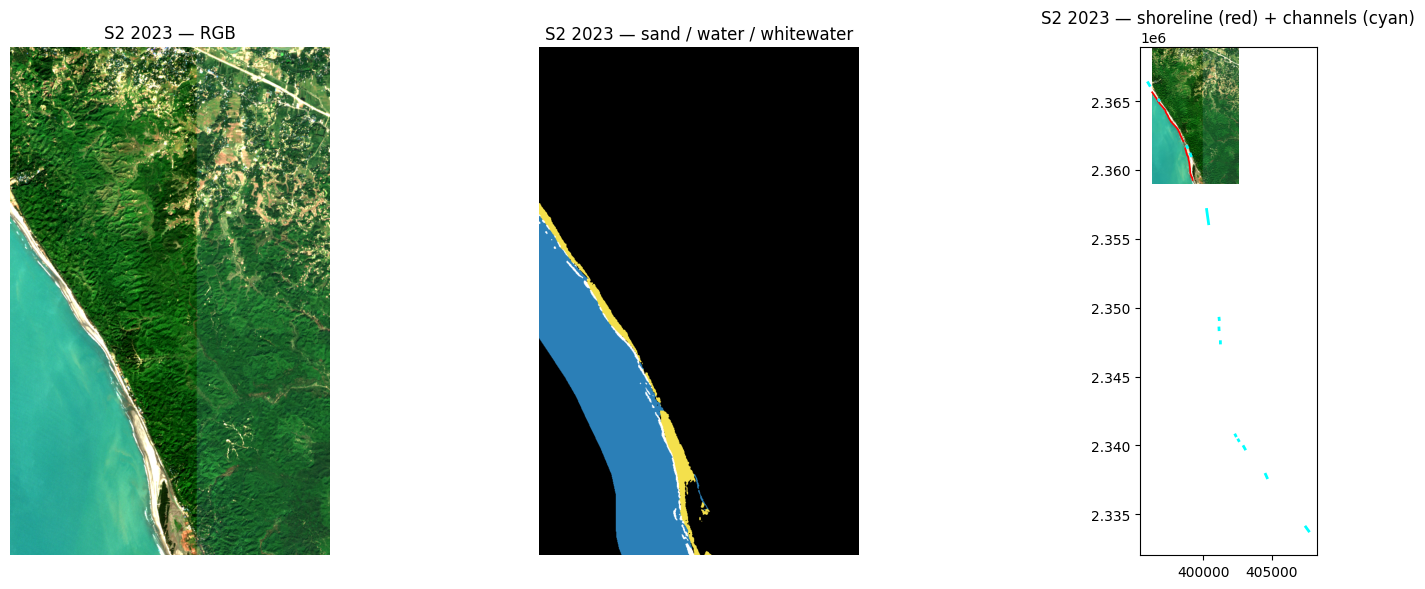

In [ ]:
CHECK_SENSOR = 'S2'    # <-- 'S2' | 'L9' | 'L8' | 'L5' | 'L7'
CHECK_YEAR   = 2023    # <-- matching label/test year, e.g. L9->2022, L5->2006
config.SHORELINE_MODE = 'envelope'   # <-- flip to 'raw' for the full sub-pixel cartographic line

_tag = f'{CHECK_SENSOR} {CHECK_YEAR}'
_group = extract.sensor_group(CHECK_SENSOR)   # S2->MSI, L8/L9->OLI, L4/L5/L7->TM
if _group not in classifiers:
    print(f'BLOCKED: no {_group} model loaded — run Notebook 03a to train {_group}.')
    line = None
else:
    settings = extract.default_settings(water_index_name='mndwi', threshold_method='otsu')
    print(f'checking {_tag} ({_group}) | mode:', settings['mode'],
          '| transects:', settings['transects'] is not None)
    # first_covering returns a pandas Series or None -> None-check, never `or`
    # (bool(Series) raises "truth value is ambiguous").
    check_row = first_covering(annual, demo_ll, sensor=CHECK_SENSOR, dry_year=CHECK_YEAR)
    if check_row is None:
        check_row = row_for(annual, sensor=CHECK_SENSOR, dry_year=CHECK_YEAR)
    if check_row is None:
        raise ValueError(f'no {_tag} scene in the inventory — pick a year that exists for this sensor')
    sc = extract.fetch_scene(check_row, region_utm=demo_utm)   # demo window: light + fast
    labels = extract.classify_scene(sc, classifiers[_group])
    idx = extract.water_index(sc, 'mndwi')
    thr = extract.interface_threshold(idx, labels, 'otsu')
    contours = extract.extract_contour(idx, thr, extract.interface_mask(labels, sc.valid), sc.transform)
    audit = {}
    line = extract.filter_contours(contours, settings['search_zone'], settings['channel_lines'],
                                   mode=settings['mode'], transects=settings['transects'],
                                   watermask=(labels, sc.transform, sc.valid), audit=audit)
    print(f'{_tag}: interface Otsu threshold:', round(float(thr), 4),
          '| contour segments:', len(contours),
          '| shoreline length_m:', None if line is None else round(line.length, 1))
    # Fragmentation diagnostics (the anti-fragmentation fixes): the raw contour
    # should be a FEW long pieces (not dozens), and the envelope near-continuous.
    _cov = 0.0 if line is None else min(100.0, 100.0 * line.length / extract.AOI_ALONGSHORE_M)
    print(f'{_tag}: fragmentation -> contour n_parts:', len(contours),
          '| envelope n_parts:', extract._count_parts(line),
          '| n_points:', extract._count_vertices(line),
          '| n_bridged_gaps:', audit.get('envelope_n_bridged_gaps'),
          '| pct_aoi_alongshore_covered: %.1f%%' % _cov)
    print('   (demo window spans only part of the 92 km coast, so pct here is low '
          'by design — the full-coast pct is in the batch records below.)')
    if settings['mode'] == 'envelope' and settings['transects'] is not None:
        m = audit.get('seaward_methods', {})
        res = m.get('watermask', 0) + m.get('baseline_normal', 0) + m.get('land_is_east', 0)
        pct = 100.0 * m.get('watermask', 0) / res if res else 0.0
        print(f"seaward: watermask={m.get('watermask',0)} ({pct:.1f}%) "
              f"baseline_normal={m.get('baseline_normal',0)} land_is_east={m.get('land_is_east',0)} "
              f"| fb no_water={m.get('fb_no_water',0)} no_sand={m.get('fb_no_sand',0)} "
              f"tie={m.get('fb_tie',0)} no_labels={m.get('fb_no_labels',0)} "
              f"| n_multi={audit.get('envelope_n_multi')} | skipped_nodata={audit.get('envelope_skipped_nodata')}")

    t, (H, W) = sc.transform, sc.valid.shape
    extent = [t.c, t.c + W * t.a, t.f + H * t.e, t.f]
    overlay = np.zeros((H, W, 3))
    overlay[labels == config.CLASS_SAND] = [0.96, 0.88, 0.30]
    overlay[labels == config.CLASS_WATER] = [0.17, 0.50, 0.72]
    overlay[labels == config.CLASS_WHITEWATER] = [1.0, 1.0, 1.0]
    fig, ax = plt.subplots(1, 3, figsize=(17, 6))
    ax[0].imshow(rgb_from_scene(sc)); ax[0].set_title(f'{_tag} — RGB'); ax[0].axis('off')
    ax[1].imshow(overlay); ax[1].set_title(f'{_tag} — sand / water / whitewater'); ax[1].axis('off')
    ax[2].imshow(rgb_from_scene(sc), extent=extent, origin='upper')
    if line is not None:
        for ln in extract._as_line_list(line):
            xs, ys = ln.xy; ax[2].plot(xs, ys, '-', color='red', lw=1.2)
    for cl in settings['channel_lines']:
        xs, ys = cl.xy; ax[2].plot(xs, ys, color='cyan', lw=2)
    ax[2].set_aspect('equal'); ax[2].set_title(f'{_tag} — shoreline (red) + channels (cyan)')
    plt.tight_layout(); plt.show()

## Zoomed comparison — how tightly the contour follows the waterline

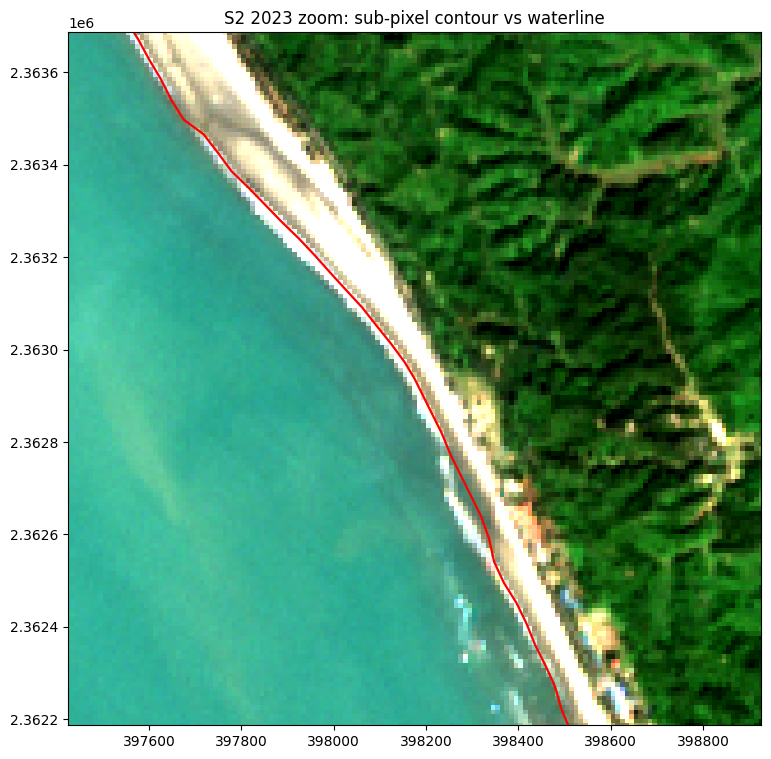

In [ ]:
if 'line' in globals() and line is not None:
    mid = line.interpolate(0.5, normalized=True); half = 750
    fig, ax = plt.subplots(figsize=(9, 9))
    ax.imshow(rgb_from_scene(sc), extent=extent, origin='upper')
    for ln in extract._as_line_list(line):
        xs, ys = ln.xy; ax.plot(xs, ys, '-', color='red', lw=1.6)
    ax.set_xlim(mid.x - half, mid.x + half); ax.set_ylim(mid.y - half, mid.y + half)
    ax.set_aspect('equal')
    ax.set_title(f"{globals().get('_tag', 'scene')} zoom: sub-pixel contour vs waterline")
    plt.show()
else:
    print('Run the extraction cell first.')

## Batch extraction — Series A, then Series B

`extract_all` checkpoints `sds_scenes.geojson` after **every** scene to the local
`outputs/shorelines/` **AND the Drive mirror**
(`…/shoreline_dynamics/shorelines/`), and **resumes from the durable Drive copy** —
so a mid-run disconnect on the 829-scene Series B run is recoverable, not a total
loss. It frees each scene (`del`+`gc`) and prints per-scene `rss`/`peak` RAM.
`persist_shoreline_outputs` then writes the merged annual file to Drive + local and
**pushes `outputs/` to GitHub** (needs a `GITHUB_TOKEN` Colab secret; prints the
resolved paths + push status). Needs a classifier for every group the list uses —
missing ones point you to Notebook 03a (this notebook never trains).

**Checkpoint invalidation:** the checkpoint is stamped with the transects/baseline
it was built from. If you **edit the baseline + rebuild transects** (above), the
stamp no longer matches and `extract_all` **re-extracts every scene from scratch**
automatically — a stale result is never reused against new geometry. A true
disconnect (geometry unchanged) still resumes. `FORCE_REEXTRACT = True` forces a
clean full re-extraction regardless. Watch the batch-start line to see which path
it took.

In [10]:
FORCE_REEXTRACT = False   # <-- True to re-extract every scene regardless of checkpoint
missing_A = [g for g in needed if not extract.model_exists(g)]
if missing_A:
    print('BLOCKED: Series A needs classifiers for', needed, '- missing:', missing_A)
    print('Run Notebook 03a to train the missing groups, then re-run this cell.')
else:
    settings = extract.default_settings()
    gdfA = extract.extract_all(annual, settings, classifiers=classifiers,
                               force_reextract=FORCE_REEXTRACT)   # Drive-checkpointed + stamp-invalidated
    merged = extract.merge_annual(gdfA)
    print('Series A scenes:', len(gdfA), '-> merged segments:', len(merged))
    # Fragmentation health across the batch (the anti-fragmentation fixes): on clean
    # scenes expect contour_n_parts in the low tens or fewer, envelope_n_parts small,
    # and pct_aoi_alongshore_covered ~95-100%. Worst offenders are listed to inspect.
    _frag = [c for c in ('contour_n_parts', 'envelope_n_parts', 'envelope_n_bridged_gaps',
                         'pct_aoi_alongshore_covered') if c in gdfA.columns]
    if _frag:
        _g = gdfA[gdfA['length_m'] > 0]
        print('\nfragmentation summary (scenes with a shoreline):')
        print(_g[_frag].describe().loc[['mean', '50%', 'min', 'max']].round(1).to_string())
        _cols = ['sensor', 'dry_year'] + _frag
        _worst = _g.sort_values('pct_aoi_alongshore_covered').head(6)
        print('\nlowest coverage (inspect these):')
        print(_worst[[c for c in _cols if c in _g.columns]].to_string(index=False))
    # Persist sds_scenes + sds_annual_merged to Drive + local outputs/, and push to GitHub.
    extract.persist_shoreline_outputs(scenes_gdf=gdfA, merged_gdf=merged, push=True)

# Series B (hundreds of scenes) — same call; the Drive checkpoint makes it resumable:
#   if not [g for g in ('TM','OLI','MSI') if not extract.model_exists(g)]:
#       gdfB = extract.extract_all(dense, extract.default_settings(), classifiers=classifiers)
#       extract.persist_shoreline_outputs(scenes_gdf=gdfB, push=True)

checkpoint -> outputs/shorelines/sds_scenes.geojson, /content/drive/MyDrive/shoreline_dynamics/shorelines/sds_scenes.geojson
resuming from checkpoint (geometry unchanged, 60 scenes done) <- /content/drive/MyDrive/shoreline_dynamics/shorelines/sds_scenes.geojson
Series A scenes: 60 -> merged segments: 60

fragmentation summary (scenes with a shoreline):
      contour_n_parts  envelope_n_parts  envelope_n_bridged_gaps  pct_aoi_alongshore_covered
mean            146.3              14.0                      6.4                        75.0
50%             106.0               7.0                      4.5                        80.6
min              39.0               1.0                      0.0                        29.8
max             659.0              73.0                     20.0                       100.0

lowest coverage (inspect these):
sensor  dry_year  contour_n_parts  envelope_n_parts  envelope_n_bridged_gaps  pct_aoi_alongshore_covered
    L7      2013              124        

In [11]:
   import inspect, src.extract as ex
   print("nearest-neighbour fill present:", "distance_transform_edt" in inspect.getsource(ex.extract_contour))
   print("bridge present:", "ENVELOPE_MAX_BRIDGE_GAP" in inspect.getsource(ex.seaward_envelope))

nearest-neighbour fill present: True
bridge present: True


## Benchmark — reference-scene export

Export the benchmark scenes (full coastal ribbon via the search zone) to Drive so
you can digitise a validation shoreline on each in QGIS. **Tag each reference line
with `src_year` + `src_sensor`** matching the exported scene (printed below) — the
benchmark matches references to scenes by `(src_year, src_sensor)`. Default set:
MSI 2019 & 2024; OLI 2022 (L9) & 2016 (L8); TM 2006 & 2009.

In [ ]:
REF_SCENES = [('S2', 2019), ('S2', 2024), ('L9', 2022), ('L8', 2016), ('L5', 2006), ('L5', 2009)]
export_dir = ('/content/drive/MyDrive/shoreline_dynamics'
              if os.path.isdir('/content/drive/MyDrive') else 'outputs')
os.makedirs(export_dir, exist_ok=True)
region = None if os.path.exists(config.SEARCH_ZONE_PATH) else demo_utm   # full coast if search zone exists
for sensor, yr in REF_SCENES:
    row = row_for(annual, sensor=sensor, dry_year=yr)
    if row is None:
        print(f'{sensor} {yr}: no scene in the inventory -> skip')
        continue
    tif = os.path.join(export_dir, f'refscene_{yr}_{sensor}_utm46n.tif')
    extract.export_scene_geotiff(row, tif, bands=('red', 'green', 'blue', 'swir1'), region_utm=region)
    print(f'{sensor} {yr}: wrote {tif}')
    print(f'   -> digitise a reference LineString along the wet/dry line; tag src_year={yr}, src_sensor={sensor!r}')

## Benchmark — load reference shorelines

Read every `data/reference_shorelines/*.geojson` into one layer and report the line
count per `(src_year, src_sensor)`. Warns if a file lacks those fields (it would
then fall back to `image_id` matching).

In [12]:
import glob
ref_files = sorted(glob.glob('data/reference_shorelines/*.geojson'))
refs = None
if not ref_files:
    print('no data/reference_shorelines/*.geojson yet -> export scenes above, digitise, upload.')
else:
    parts = []
    for f in ref_files:
        g = gpd.read_file(f)
        if not {'src_year', 'src_sensor'} <= set(g.columns):
            print(f'WARNING: {f} lacks src_year/src_sensor -> falls back to image_id matching')
        parts.append(g)
    refs = gpd.GeoDataFrame(pd.concat(parts, ignore_index=True), crs=parts[0].crs)
    print(f'loaded {len(refs)} reference lines from {len(ref_files)} file(s)')
    if {'src_year', 'src_sensor'} <= set(refs.columns):
        print('lines per (src_year, src_sensor):')
        print(refs.groupby(['src_year', 'src_sensor']).size().to_string())

loaded 25 reference lines from 1 file(s)
lines per (src_year, src_sensor):
src_year  src_sensor
1989      L5            5
2006      L5            5
2009      L5            5
2022      L9            5
2023      S2            5


## Benchmark — run the grid + best config + inter-sensor bias

Grid-searches `water_index × threshold_method × classifier(local/none)` against the
references (matched by `(src_year, src_sensor)`), prints the per-config table, the
BEST (min-RMSE) config per sensor group, and the inter-sensor offsets from the
Series A shorelines.

In [13]:
if refs is None:
    print('BLOCKED: load references first (cell above).')
elif transects is None:
    print('BLOCKED: no transects — digitise data/baseline.geojson (03a artifacts).')
else:
    # Fetch each reference scene at full-coast, matched by (src_year, src_sensor).
    ref_scenes = []
    if {'src_year', 'src_sensor'} <= set(refs.columns):
        for _, k in refs[['src_year', 'src_sensor']].drop_duplicates().iterrows():
            r = row_for(annual, sensor=str(k['src_sensor']), dry_year=int(k['src_year']))
            if r is not None:
                ref_scenes.append(extract.fetch_scene(r))
    print(f'fetched {len(ref_scenes)} reference scenes')
    bm = extract.benchmark_extraction(ref_scenes, refs, transects=transects,
                                      classifiers=classifiers, use_classifier_options=(True, False))
    pd.set_option('display.width', 170)
    print('\n=== grid: per (sensor_group, water_index, threshold_method, classifier) ===')
    print(bm.to_string(index=False))
    local = bm[bm['classifier'] == 'local']
    if len(local):
        best = local.loc[local.groupby('sensor_group')['rmse_m'].idxmin()]
        print('\n=== BEST config per sensor group (min rmse, local classifier) ===')
        print(best[['sensor_group', 'water_index', 'threshold_method',
                    'rmse_m', 'bias_m', 'mae_m', 'n']].to_string(index=False))
    if 'gdfA' in globals():
        print('\n=== inter-sensor bias (near-coincident cross-sensor pairs) ===')
        print(extract.intersensor_bias(gdfA, transects=transects).to_string(index=False))
    else:
        print('\n(run the Series A batch cell first to get gdfA for intersensor_bias)')

fetched 5 reference scenes

=== grid: per (sensor_group, water_index, threshold_method, classifier) ===
sensor_group water_index threshold_method classifier     rmse_m      bias_m      mae_m   n  n_multi_excluded
          TM       mndwi             otsu      local  20.142985  -17.059270  17.476193 272               301
         OLI       mndwi             otsu      local   8.912701   -5.065610   6.883751  62                90
         MSI       mndwi             otsu      local   7.113617   -2.276301   5.245216  73                60
          TM       mndwi   weighted_peaks      local  11.121057   -1.384817   8.752915 296               245
         OLI       mndwi   weighted_peaks      local   8.912701   -5.065610   6.883751  62                90
         MSI       mndwi   weighted_peaks      local   7.113617   -2.276301   5.245216  73                60
          TM        ndwi             otsu      local  17.083153   -8.130685  14.632851  72               107
         OLI        ndwi

## Controlled ladder — CoastSat (A) vs conventional-on-our-data (B) vs ours (C)

Loads the CoastSat-default shorelines from `data/coastsat_baseline/` (run notebook
**04** first), scores them with `extract.score_external_shorelines` — the **identical**
transect-offset metric as the benchmark (same `_transect_offsets`, same multi-crossing
exclusion, same references + transects) — and prints the ladder per sensor group:
**A** CoastSat default → **B** conventional (our SR + `classifier='none'` + MNDWI/Otsu,
best row) → **C** ours (`classifier='local'`, best row). **A→B** isolates the
tool/inputs (TOA + generic classifier vs our SR pipeline); **B→C** isolates our
sub-pixel local-classifier method.

In [ ]:
import glob
cs_files = sorted(glob.glob('data/coastsat_baseline/*.geojson'))
if not cs_files:
    print('no data/coastsat_baseline/*.geojson -> run notebook 04 (CoastSat baseline) first.')
elif refs is None or transects is None or 'bm' not in globals():
    print('BLOCKED: need references + transects + the benchmark grid (bm) from the cells above.')
else:
    cs = gpd.GeoDataFrame(pd.concat([gpd.read_file(f) for f in cs_files], ignore_index=True))
    cs = cs.set_crs('EPSG:4326', allow_override=True)
    A = extract.score_external_shorelines(cs, refs, transects=transects)   # config A (CoastSat)

    def _best(clf):   # best benchmark row per sensor group (min rmse) for a classifier arm
        d = bm[bm['classifier'] == clf]
        return d.loc[d.groupby('sensor_group')['rmse_m'].idxmin()] if len(d) else d
    def _tag(df, t):
        return df[['sensor_group', 'rmse_m', 'bias_m', 'mae_m']].rename(
            columns={'rmse_m': f'{t}_rmse', 'bias_m': f'{t}_bias', 'mae_m': f'{t}_mae'})

    ladder = _tag(A, 'A_coastsat').merge(_tag(_best('none'), 'B_conv'), on='sensor_group', how='outer') \
                                  .merge(_tag(_best('local'), 'C_ours'), on='sensor_group', how='outer')
    pd.set_option('display.width', 200)
    print('=== ladder A (CoastSat) -> B (conventional/our SR) -> C (our method), per sensor group ===')
    print(ladder.to_string(index=False))
    print('\nrmse_m only (lower = better):')
    print(ladder[['sensor_group', 'A_coastsat_rmse', 'B_conv_rmse', 'C_ours_rmse']].to_string(index=False))

### Reading the benchmark

- **rmse_m** (transect-normal error vs the manual reference): **≤15 m good**;
  **15–20 m acceptable** for this mesotidal (~3 m spring range), turbid GBM coast;
  **>20 m** ⇒ residual tide/turbidity dominates the per-date scatter — that is the
  signal to proceed to **Phase 3** (FES2022 tidal correction), not a extraction bug.
- **classifier `local` vs `none`**: the RMSE drop from `none` to `local` is the
  value of the local sand/water training (interface threshold vs a whole-scene one).
- **bias_m** per sensor group: a consistent sign is the **inter-sensor offset** to
  correct in **Phase 4** before multi-decadal rates; `intersensor_bias` gives the
  pairwise offsets directly.
- Pick the operational **water_index × threshold_method** from the BEST rows and set
  `config.WATER_INDEX_DEFAULT` / `config.THRESHOLD_METHOD_DEFAULT`.

## Operator artifacts (digitise in QGIS, upload via the GitHub web interface)

Upload under `data/` on GitHub, then `git pull` in the setup cell.

**`data/shoreline_search_zone.geojson`** — one polygon (EPSG:4326) enclosing every
plausible shoreline 1988–2025 (±300 m about the present shoreline, widening to
±800–1000 m within ~3 km of the Bakkhali and Naf mouths).

**`data/training_polygons.geojson`** — labelled polygons, `class` ∈ {`other`,
`sand`, `whitewater`, `water`}, each tagged with **`src_year`** and **`src_sensor`**
(the dry-year + sensor of the scene it was digitised over, e.g. 2023 / `S2`). ~6
scenes per sensor group (TM = L4/L5/L7, OLI = L8/L9, MSI = S2), spread along the
AOI; aim for ≥5,000 labelled pixels per class per group.

**`data/reference_shorelines/`** — 10 manually digitised validation shorelines
(LineStrings, EPSG:4326) with an `image_id` matching the scene, along the wet/dry
line. Used by `benchmark_extraction()`.

**`data/baseline.geojson`** — a LineString / MultiLineString landward of and roughly
parallel to the coast, **broken at the Naf and Bakkhali mouths** (transects are
cast per segment, never across a gap). Seaward direction is set automatically from
`config.SEAWARD_REFERENCE_LONLAT`.